In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
df1=pd.read_csv(r"C:\Users\singireddyUdayasri\Downloads\nyc_yellow_taxi\yellow_tripdata_2016-03.csv")

In [3]:
df1

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,1,N,-74.004265,40.746128,1,9.0,0.5,0.5,2.05,0.00,0.3,12.35
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,1,N,-74.005943,40.733166,1,11.0,0.5,0.5,3.05,0.00,0.3,15.35
2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,19.98,-73.782021,40.644810,1,N,-73.974541,40.675770,1,54.5,0.5,0.5,8.00,0.00,0.3,63.80
3,2,2016-03-01 00:00:00,2016-03-01 00:00:00,3,10.78,-73.863419,40.769814,1,N,-73.969650,40.757767,1,31.5,0.0,0.5,3.78,5.54,0.3,41.62
4,2,2016-03-01 00:00:00,2016-03-01 00:00:00,5,30.43,-73.971741,40.792183,3,N,-74.177170,40.695053,1,98.0,0.0,0.0,0.00,15.50,0.3,113.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12210947,1,2016-03-31 16:34:36,2016-03-31 16:34:36,1,0.00,0.000000,0.000000,1,Y,0.000000,0.000000,2,19.0,1.0,0.5,0.00,0.00,0.3,20.80
12210948,1,2016-03-26 03:02:32,2016-06-14 18:47:55,1,0.40,-73.977356,40.774471,1,N,-73.982536,40.772408,1,4.0,1.0,0.5,1.70,0.00,0.3,7.50
12210949,1,2016-03-20 08:43:59,2016-06-27 15:05:01,1,20.20,0.000000,0.000000,2,N,-74.008614,40.710987,1,52.0,0.0,0.5,6.00,5.54,0.3,64.34
12210950,1,2016-03-20 08:49:47,2016-06-28 19:11:27,1,15.40,-73.790077,40.647377,1,N,-73.971756,40.578457,1,42.5,1.0,0.5,5.00,0.00,0.3,49.30


In [4]:
df1.shape

(12210952, 19)

In [10]:
df1.select_dtypes(include="int").nunique()

VendorID            2
passenger_count    10
RatecodeID          7
payment_type        4
dtype: int64

In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12210952 entries, 0 to 12210951
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RatecodeID             int64  
 8   store_and_fwd_flag     object 
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
dtypes: float64(12), int64(4), object(3)
memory usage: 1.7+ GB


In [6]:
df1.isna().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

In [7]:
df1.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag',
       'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount',
       'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
       'improvement_surcharge', 'total_amount'],
      dtype='object')

In [8]:
df1.select_dtypes(include="object").nunique()

tpep_pickup_datetime     2462580
tpep_dropoff_datetime    2466342
store_and_fwd_flag             2
dtype: int64

In [9]:
df1.duplicated().sum()

np.int64(1)

In [10]:
df1["tpep_pickup_datetime"] = pd.to_datetime(
    df1["tpep_pickup_datetime"],
    errors="coerce"
)

In [11]:
df1["tpep_dropoff_datetime"] = pd.to_datetime(
    df1["tpep_dropoff_datetime"],
    errors="coerce"
)

In [12]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12210952 entries, 0 to 12210951
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        int64         
 4   trip_distance          float64       
 5   pickup_longitude       float64       
 6   pickup_latitude        float64       
 7   RatecodeID             int64         
 8   store_and_fwd_flag     object        
 9   dropoff_longitude      float64       
 10  dropoff_latitude       float64       
 11  payment_type           int64         
 12  fare_amount            float64       
 13  extra                  float64       
 14  mta_tax                float64       
 15  tip_amount             float64       
 16  tolls_amount           float64       
 17  improvement_surcharge  float64       
 18  total_amount        

In [13]:
df1["VendorID"].value_counts()

VendorID
2    6479710
1    5731242
Name: count, dtype: int64

In [14]:
df1["trip_duration_minutes"]=(df1["tpep_dropoff_datetime"]-df1["tpep_pickup_datetime"]).dt.total_seconds()/60

In [15]:
df1["trip_duration_minutes"].describe()

count    1.221095e+07
mean     1.569321e+01
std      1.152610e+02
min     -5.052023e+04
25%      6.533333e+00
50%      1.088333e+01
75%      1.758333e+01
max      1.458679e+05
Name: trip_duration_minutes, dtype: float64

In [16]:
df1[df1["trip_duration_minutes"] < 0].shape

(109, 20)

In [17]:
df1[df1["trip_duration_minutes"] > 1440].shape

(14, 20)

In [18]:
df1_clean=df1[(df1["trip_duration_minutes"] > 0) & (df1["trip_duration_minutes"]<=1440)]

In [19]:
df1_clean.shape

(12198388, 20)

In [20]:
df1_clean["trip_distance"].describe()

count    1.219839e+07
mean     6.137757e+00
std      6.159652e+03
min      0.000000e+00
25%      1.000000e+00
50%      1.700000e+00
75%      3.180000e+00
max      1.907263e+07
Name: trip_distance, dtype: float64

In [21]:
df1_clean[df1_clean["trip_distance"] ==0].shape

(59025, 20)

In [22]:
df1_clean[df1_clean["trip_distance"] == 0]["fare_amount"].describe()

count     59025.000000
mean         28.888319
std        1768.170751
min        -376.000000
25%           2.500000
50%           3.000000
75%          40.000000
max      429496.720000
Name: fare_amount, dtype: float64

In [23]:
df1_clean[(df1_clean["trip_distance"]==0) & (df1_clean["fare_amount"] > 0)].shape

(56935, 20)

In [24]:
df1_clean[(df1_clean["trip_distance"] == 0) & (df1_clean["fare_amount"] > 0)]["fare_amount"].describe()

count     56935.000000
mean         30.268540
std        1800.311391
min           0.010000
25%           2.500000
50%           3.000000
75%          45.000000
max      429496.720000
Name: fare_amount, dtype: float64

In [25]:
df1_clean[(df1_clean["trip_distance"] == 0) & (df1_clean["fare_amount"] > 100)].shape

(1728, 20)

In [26]:
df1_clean["fare_amount"].describe()

count    1.219839e+07
mean     1.279546e+01
std      1.341651e+02
min     -3.760000e+02
25%      6.500000e+00
50%      9.500000e+00
75%      1.450000e+01
max      4.294967e+05
Name: fare_amount, dtype: float64

In [27]:
df1_clean[df1_clean["fare_amount"] <= 0].shape

(7767, 20)

In [28]:
df1_final=df1_clean[(df1_clean["trip_distance"] > 0) &
                     (df1_clean["fare_amount"] >0) &
                     (df1_clean["fare_amount"] < 500)
    ]

In [29]:
df1_final.shape

(12133668, 20)

In [30]:
df1_final["fare_amount"].describe()

count    1.213367e+07
mean     1.270314e+01
std      1.054540e+01
min      1.000000e-02
25%      6.500000e+00
50%      9.500000e+00
75%      1.450000e+01
max      4.950000e+02
Name: fare_amount, dtype: float64

In [31]:
df1_final["trip_distance"].describe()

count    1.213367e+07
mean     6.144339e+00
std      6.175759e+03
min      1.000000e-02
25%      1.000000e+00
50%      1.700000e+00
75%      3.200000e+00
max      1.907263e+07
Name: trip_distance, dtype: float64

In [32]:
df1_final["trip_distance"].describe(percentiles=[0.90, 0.95, 0.99])

count    1.213367e+07
mean     6.144339e+00
std      6.175759e+03
min      1.000000e-02
50%      1.700000e+00
90%      6.750000e+00
95%      1.050000e+01
99%      1.860000e+01
max      1.907263e+07
Name: trip_distance, dtype: float64

In [33]:
df1_final = df1_final[df1_final["trip_distance"] < 100]

In [34]:
df1_final.shape

(12133587, 20)

In [35]:
df1_final["trip_distance"].describe()

count    1.213359e+07
mean     2.968894e+00
std      3.614405e+00
min      1.000000e-02
25%      1.000000e+00
50%      1.700000e+00
75%      3.200000e+00
max      9.918000e+01
Name: trip_distance, dtype: float64

In [36]:
df1_final[["trip_distance", "fare_amount"]].corr()

,trip_distance,fare_amount
trip_distance,1.000000,0.946143
fare_amount,0.946143,1.000000


In [37]:
df1_final["fare_per_mile"] = df1_final["fare_amount"] / df1_final["trip_distance"]

In [38]:
df1_final["fare_per_mile"].describe(percentiles=[0.90, 0.95, 0.99])

count    1.213359e+07
mean     6.489135e+00
std      4.837559e+01
min      1.295337e-04
50%      5.319149e+00
90%      8.549223e+00
95%      1.000000e+01
99%      1.500000e+01
max      2.400000e+04
Name: fare_per_mile, dtype: float64

In [39]:
df1_final[df1_final["trip_distance"] < 0.1].shape

(14349, 21)

In [40]:
df1_pricing = df1_final[df1_final["trip_distance"] >= 0.1]

In [41]:
df1_pricing["fare_per_mile"].describe(percentiles=[0.90, 0.95, 0.99])

count    1.211924e+07
mean     5.882755e+00
std      7.336283e+00
min      1.295337e-04
50%      5.312500e+00
90%      8.510638e+00
95%      1.000000e+01
99%      1.470588e+01
max      4.000000e+03
Name: fare_per_mile, dtype: float64

In [42]:
df1_final["pickup_hour"] = df1_final["tpep_pickup_datetime"].dt.hour

In [43]:
df1_final["pickup_hour"].value_counts().sort_index()

pickup_hour
0     426720
1     305641
2     206110
3     166833
4     127332
5     124000
6     274680
7     466522
8     569865
9     568538
10    545858
11    558654
12    586153
13    587224
14    613561
15    596268
16    542206
17    646058
18    764773
19    768507
20    725543
21    713517
22    671668
23    577356
Name: count, dtype: int64

In [44]:
df1_final.groupby("pickup_hour")["fare_amount"].sum().sort_values(ascending=False)

pickup_hour
18    9214933.93
19    9022614.60
21    8939460.40
20    8819851.86
22    8808373.39
17    8312490.25
14    8173779.65
15    7945987.04
23    7817774.74
13    7513125.43
12    7325988.30
16    7261440.00
11    6965269.99
8     6887532.86
9     6885013.32
10    6736962.34
0     5695358.60
7     5575605.90
1     3926270.03
6     3613842.66
2     2597622.60
3     2193311.63
5     1970891.89
4     1924458.79
Name: fare_amount, dtype: float64

In [45]:
df1_final.groupby("pickup_hour")["fare_amount"].mean().sort_values(ascending=False)

pickup_hour
5     15.894289
4     15.113709
23    13.540649
16    13.392401
0     13.346828
15    13.326201
14    13.321870
6     13.156555
3     13.146749
22    13.114178
17    12.866477
1     12.846019
13    12.794309
2     12.603089
21    12.528728
12    12.498423
11    12.467950
10    12.341969
20    12.156208
9     12.110032
8     12.086254
18    12.049241
7     11.951432
19    11.740446
Name: fare_amount, dtype: float64

In [46]:
df1_final.groupby("pickup_hour")["trip_distance"].mean().sort_values(ascending=False)

pickup_hour
5     4.683321
4     4.287029
6     3.615331
3     3.521245
0     3.471197
23    3.457211
1     3.354053
2     3.312022
22    3.269833
21    3.085422
16    3.039403
14    2.983734
15    2.968529
20    2.927518
7     2.886509
17    2.864855
13    2.813048
12    2.678216
19    2.666838
11    2.663176
10    2.642979
18    2.638487
8     2.623307
9     2.548104
Name: trip_distance, dtype: float64

In [47]:
df1_final.groupby("pickup_hour")["fare_amount"].sum() / df1_final.groupby("pickup_hour")["fare_amount"].count()


pickup_hour
0     13.346828
1     12.846019
2     12.603089
3     13.146749
4     15.113709
5     15.894289
6     13.156555
7     11.951432
8     12.086254
9     12.110032
10    12.341969
11    12.467950
12    12.498423
13    12.794309
14    13.321870
15    13.326201
16    13.392401
17    12.866477
18    12.049241
19    11.740446
20    12.156208
21    12.528728
22    13.114178
23    13.540649
Name: fare_amount, dtype: float64

In [48]:
hourly_revenue = df1_final.groupby("pickup_hour")["fare_amount"].sum()

In [49]:
revenue_share = hourly_revenue / hourly_revenue.sum() * 100

In [50]:
revenue_share.sort_values(ascending=False)

pickup_hour
18    5.978756
19    5.853977
21    5.800025
20    5.722422
22    5.714974
17    5.393240
14    5.303243
15    5.155448
23    5.072263
13    4.874603
12    4.753186
16    4.711306
11    4.519148
8     4.468711
9     4.467076
10    4.371019
0     3.695214
7     3.617517
1     2.547409
6     2.344703
2     1.685368
3     1.423046
5     1.278737
4     1.248611
Name: fare_amount, dtype: float64

In [51]:
df1_final["payment_type"].value_counts(normalize=True) * 100

payment_type
1    66.766505
2    32.834635
3     0.291769
4     0.107091
Name: proportion, dtype: float64

In [52]:
df1_final.groupby("payment_type")["fare_amount"].sum() / df1_final["fare_amount"].sum() * 100

payment_type
1    69.213027
2    30.325925
3     0.338756
4     0.122292
Name: fare_amount, dtype: float64

In [53]:
df1_final.groupby("payment_type")["fare_amount"].sum()

payment_type
1    1.066766e+08
2    4.674073e+07
3    5.221177e+05
4    1.884861e+05
Name: fare_amount, dtype: float64

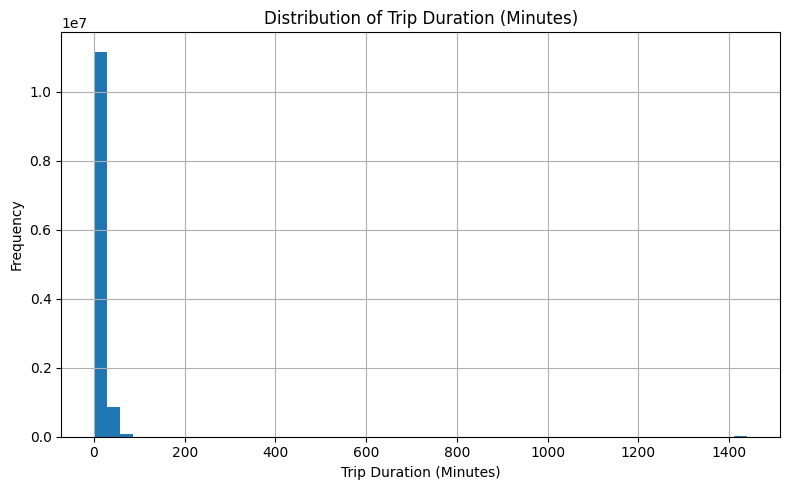

In [54]:
plt.figure(figsize=(8,5))
df1_final["trip_duration_minutes"].hist(bins=50)

plt.title("Distribution of Trip Duration (Minutes)")
plt.xlabel("Trip Duration (Minutes)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

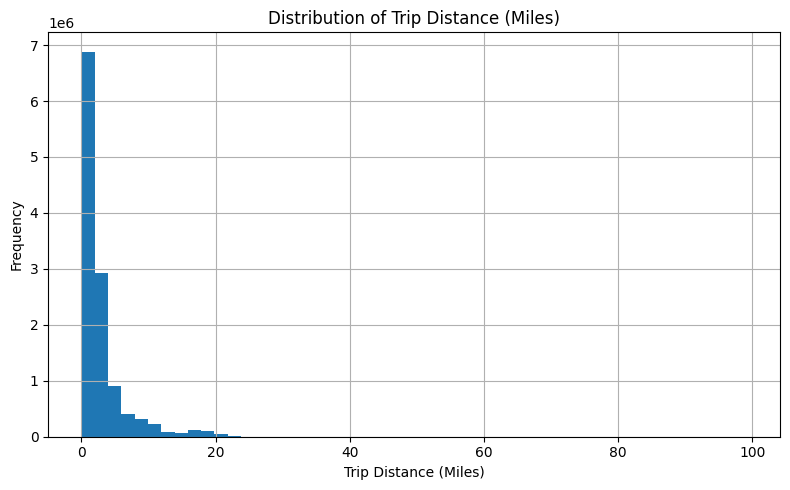

In [55]:
plt.figure(figsize=(8,5))
df1_final["trip_distance"].hist(bins=50)

plt.title("Distribution of Trip Distance (Miles)")
plt.xlabel("Trip Distance (Miles)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

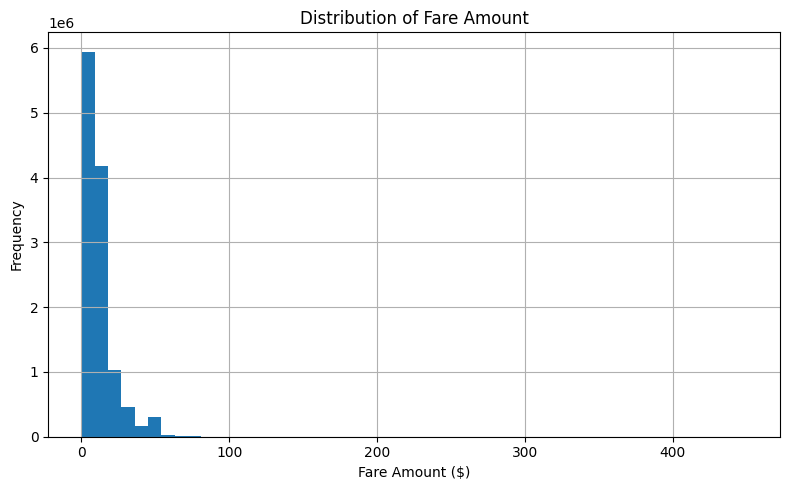

In [56]:
plt.figure(figsize=(8,5))
df1_final["fare_amount"].hist(bins=50)

plt.title("Distribution of Fare Amount")
plt.xlabel("Fare Amount ($)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

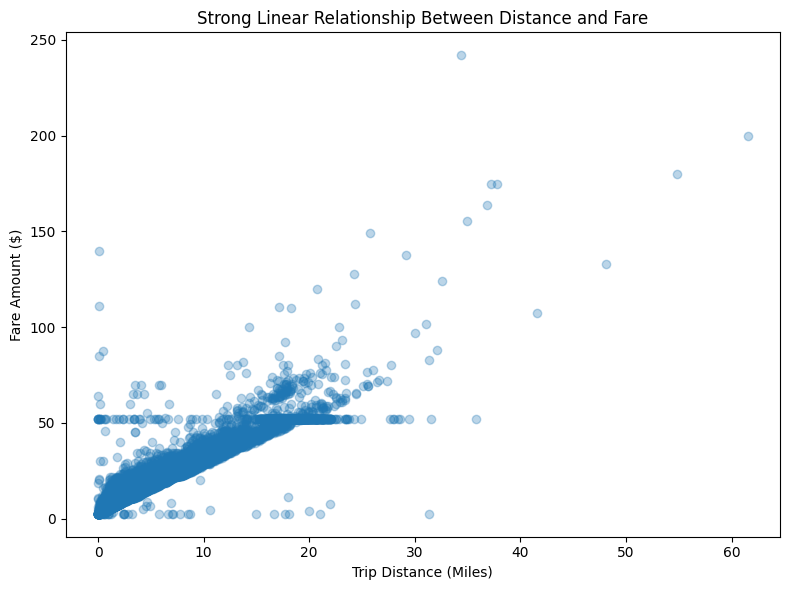

In [57]:
plt.figure(figsize=(8,6))

sample_df = df1_final.sample(50000)
plt.scatter(sample_df["trip_distance"],
            sample_df["fare_amount"],
            alpha=0.3)

plt.title("Strong Linear Relationship Between Distance and Fare")
plt.xlabel("Trip Distance (Miles)")
plt.ylabel("Fare Amount ($)")

plt.tight_layout()
plt.show()

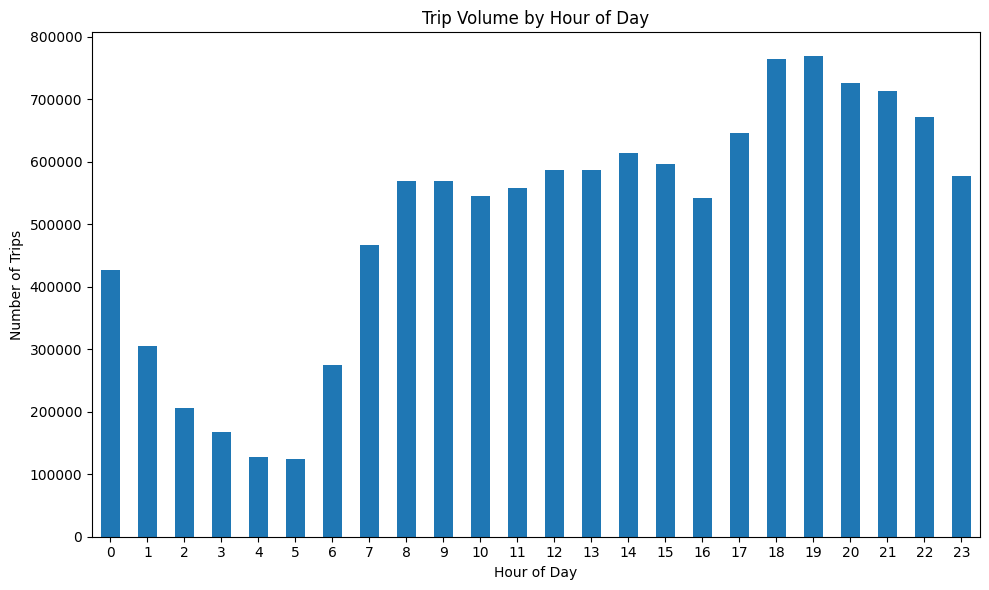

In [58]:
hourly_trips = df1_final.groupby("pickup_hour").size()

plt.figure(figsize=(10,6))
hourly_trips.plot(kind="bar")

plt.title("Trip Volume by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

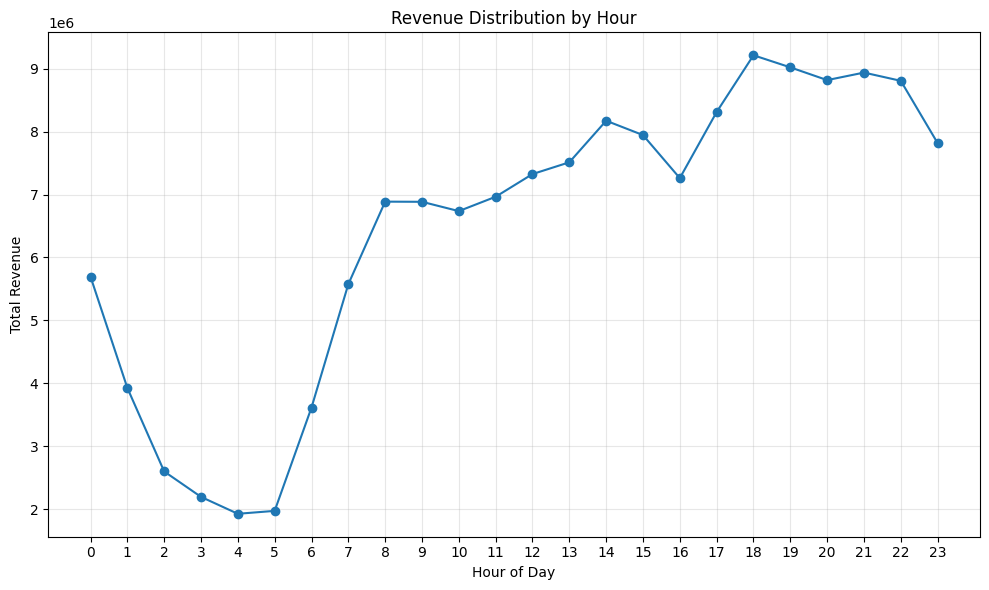

In [59]:
hourly_revenue = df1_final.groupby("pickup_hour")["fare_amount"].sum()

plt.figure(figsize=(10,6))
hourly_revenue.plot(marker="o")

plt.title("Revenue Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Revenue")

plt.xticks(range(0,24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

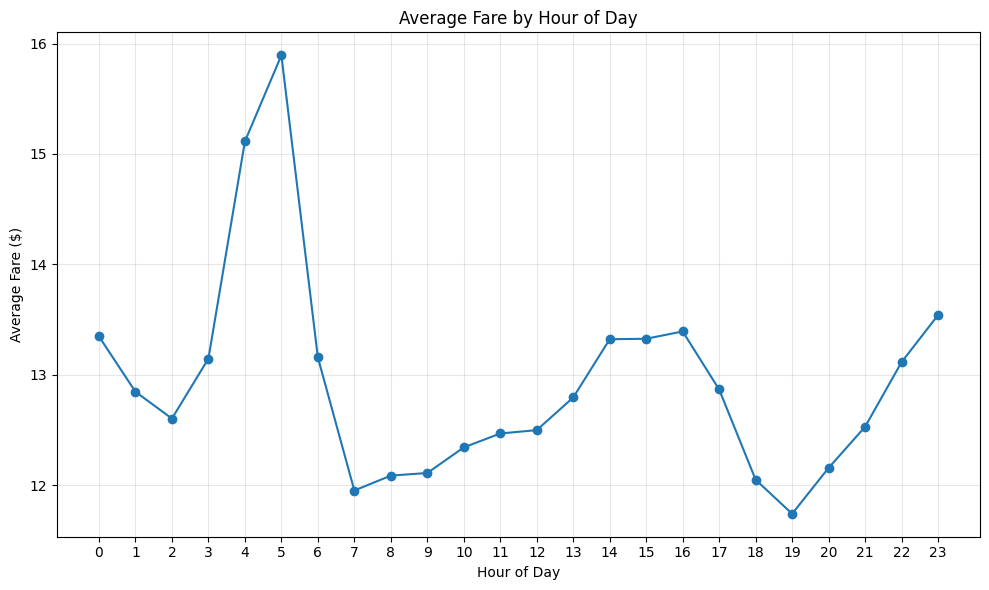

In [60]:
avg_fare = df1_final.groupby("pickup_hour")["fare_amount"].mean()

plt.figure(figsize=(10,6))
avg_fare.plot(marker="o")

plt.title("Average Fare by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Fare ($)")

plt.xticks(range(0,24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

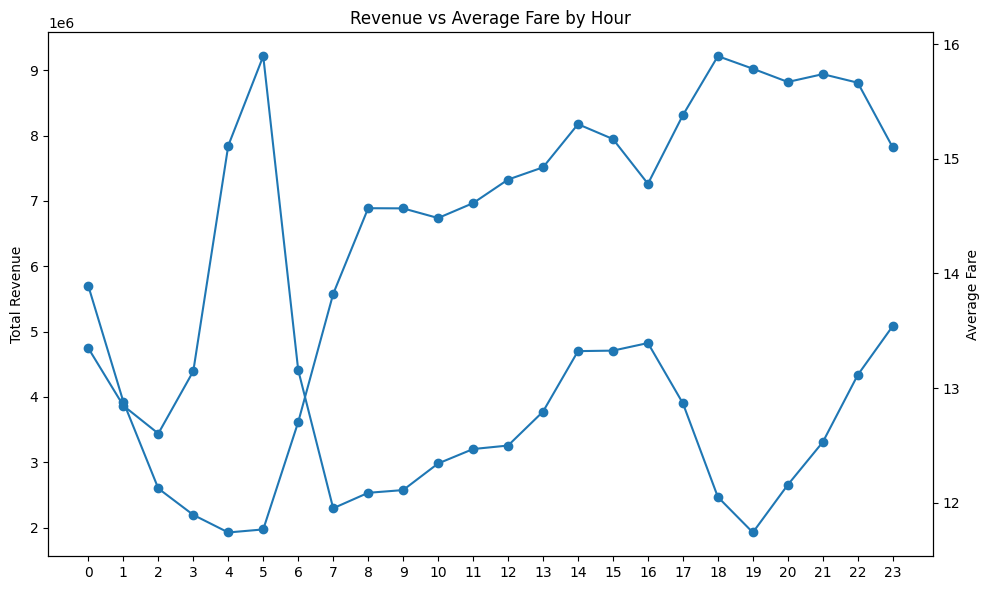

In [61]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(hourly_revenue, marker="o")
ax1.set_ylabel("Total Revenue")

ax2 = ax1.twinx()
ax2.plot(avg_fare, marker="o")
ax2.set_ylabel("Average Fare")

plt.title("Revenue vs Average Fare by Hour")
plt.xticks(range(0,24))

plt.tight_layout()
plt.show()

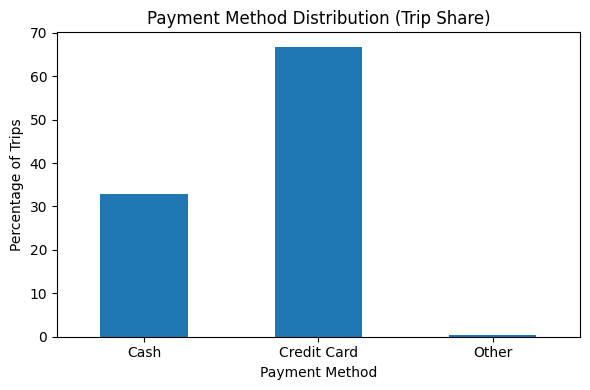

In [62]:
payment_share = df1_final["payment_type"].value_counts(normalize=True) * 100

payment_labels = {1: "Credit Card", 2: "Cash", 3: "Other", 4: "Other"}
payment_share.index = payment_share.index.map(payment_labels)
payment_share = payment_share.groupby(payment_share.index).sum()

plt.figure(figsize=(6,4))
payment_share.plot(kind="bar")

plt.title("Payment Method Distribution (Trip Share)")
plt.xlabel("Payment Method")
plt.ylabel("Percentage of Trips")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

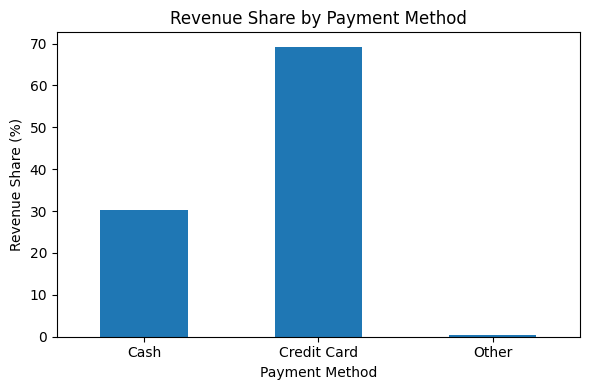

In [63]:
revenue_by_payment = df1_final.groupby("payment_type")["fare_amount"].sum()
revenue_share = revenue_by_payment / revenue_by_payment.sum() * 100

revenue_share.index = revenue_share.index.map(payment_labels)
revenue_share = revenue_share.groupby(revenue_share.index).sum()

plt.figure(figsize=(6,4))
revenue_share.plot(kind="bar")

plt.title("Revenue Share by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue Share (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()